In [1]:
# ############################################################
# 시각화 예시 — 선/히스토그램/산점도 + 실전 데이터셋으로 그리기
# ############################################################
# ------------------------------------------------------------
# [목적] 도구 + 예시 데이터 준비 (시간·나이·광고비)
#   · 앞부분: 개념 잡기용 '합성 데이터'(직접 만든 가짜 값)
#   · 중간중간: 실습에서 쓰던 '진짜 내장 데이터셋'으로 같은 그래프를 그려 봄
# ------------------------------------------------------------
import numpy as np                                # 숫자·난수 만들기 (가짜 데이터 생성)
import pandas as pd                               # 표(DataFrame)로 확인하기
import matplotlib.pyplot as plt                   # 그래프 그리기
%matplotlib inline
x = np.linspace(0, 10, 100)                       # 0~10을 100칸으로 (시간 흐름 흉내)
y = np.sin(x)                                     # 시간에 따라 오르내리는 값
age = np.random.normal(35, 10, 500)               # 나이 500명 (평균35, 퍼짐10)
ad_spend = np.random.uniform(100, 1000, 50)       # 광고비 50건 (100~1000 사이 무작위)
sales = ad_spend * 2.5 + np.random.normal(0, 500, 50)  # 매출 (광고비에 비례 + 잡음)

In [2]:
# ------------------------------------------------------------
# [데이터 살펴보기 · EDA] 그리기 전에 '표'로 먼저 확인 (광고비-매출)
#   · 그래프는 결국 숫자 표를 그림으로 바꾼 것 → 표부터 눈으로 보기
# ------------------------------------------------------------
df = pd.DataFrame({'ad_spend': ad_spend, 'sales': sales})   # 광고비·매출을 표로 묶기
print('데이터 크기(행, 열):', df.shape)           # (50, 2) 확인 (광고 캠페인 50건 × 값 2개)
df.head()                                          # 앞 5줄 미리보기 (광고비-매출 짝 확인)

데이터 크기(행, 열): (50, 2)


,ad_spend,sales
0,925.887894,1828.650107
1,415.736984,878.638058
2,136.537299,438.980317
3,974.023562,2554.142482
4,385.435526,943.857121


In [3]:
# ------------------------------------------------------------
# [데이터 살펴보기] 값 범위 요약 (min/max/평균으로 분포 감 잡기)
# ------------------------------------------------------------
df.describe().round(1)                             # 요약 통계 (광고비·매출의 최소~최대·평균)

,ad_spend,sales
count,50.0,50.0
mean,484.4,1144.0
std,241.9,779.4
min,136.5,-639.6
25%,259.2,652.9
50%,441.9,1231.7
75%,683.2,1620.0
max,974.0,2965.4


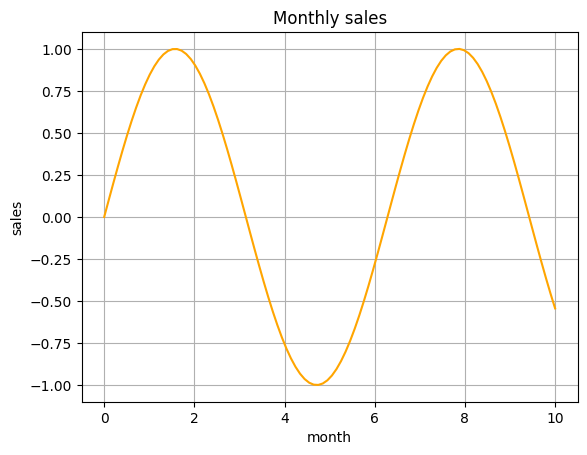

In [4]:
# ------------------------------------------------------------
# [목적] 선 그래프 — 시간에 따른 '변화'
# ------------------------------------------------------------
plt.plot(x, y, color='orange')                    # 선 그래프 (점을 선으로 이음)
plt.title('Monthly sales')                        # 제목 (한글은 깨질 수 있어 영문)
plt.xlabel('month')                               # x축 이름 (가로 = 시간)
plt.ylabel('sales')                               # y축 이름 (세로 = 값)
plt.grid(True)                                    # 눈금선 (읽기 편하게)
plt.show()                                         # 화면에 출력

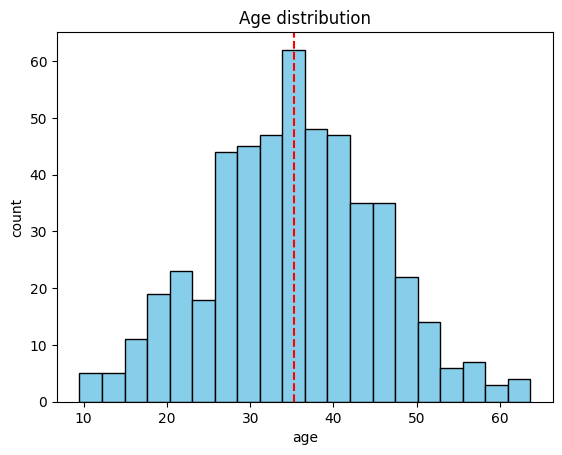

In [5]:
# ------------------------------------------------------------
# [목적] 히스토그램 — 한 값의 '분포(퍼진 모양)'
# ------------------------------------------------------------
plt.hist(age, bins=20, color='skyblue', edgecolor='black')  # 구간 20개로 개수 세기 (막대 = 그 구간 인원수)
plt.axvline(age.mean(), color='red', linestyle='dashed')    # 평균 위치에 빨간 세로선 (가운데가 어디인지)
plt.title('Age distribution')
plt.xlabel('age')                                 # x = 나이
plt.ylabel('count')                               # y = 그 나이대 인원수
plt.show()

데이터 크기: (569, 31) | target 0=악성, 1=양성


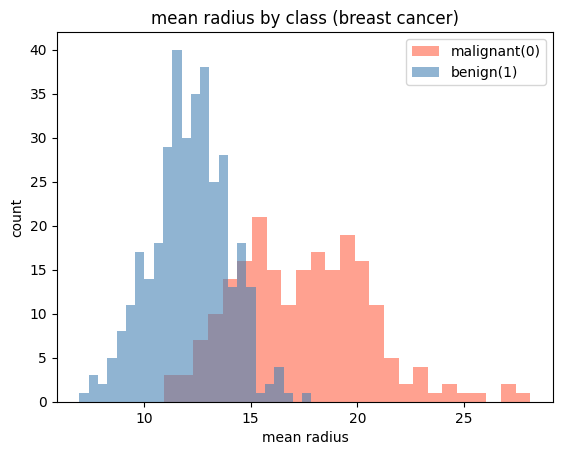

In [6]:
# ============================================================
# ★ 실전 예시 (이진분류) — 유방암 데이터로 '클래스별 히스토그램'
#   · 실습에서 이진분류(악성 0 / 양성 1)에 쓰던 그 데이터
#   · 특성 하나(mean radius)를 클래스별로 겹쳐 그리면
#     '이 특성만으로 두 그룹이 갈리는지'가 눈에 보임 → 분류 감 잡기 좋음
# ============================================================
from sklearn.datasets import load_breast_cancer   # 유방암 진단 데이터 (이진분류 연습용)
bc = load_breast_cancer(as_frame=True).frame      # 표로 불러오기 (열=특성30 + target)
print('데이터 크기:', bc.shape, '| target 0=악성, 1=양성')   # 크기·정답 의미 확인

for cls, name, color in [(0, 'malignant(0)', 'tomato'), (1, 'benign(1)', 'steelblue')]:
    plt.hist(bc[bc['target'] == cls]['mean radius'],   # 그 클래스 행들의 'mean radius'만
             bins=25, alpha=0.6, label=name, color=color)   # alpha=반투명(겹쳐 보이게)
plt.title('mean radius by class (breast cancer)')  # 제목 (클래스별 반지름 분포)
plt.xlabel('mean radius')                         # x = 세포핵 평균 반지름
plt.ylabel('count')                               # y = 개수
plt.legend()                                       # 범례 (어느 색이 어느 클래스인지)
plt.show()
# [결과 해석] 악성(빨강)이 양성(파랑)보다 반지름이 대체로 큼 → 봉우리가 오른쪽으로 치우침.
#            두 분포가 어느 정도 갈려 있어 'mean radius'가 분류에 도움되는 특성임을 시사.

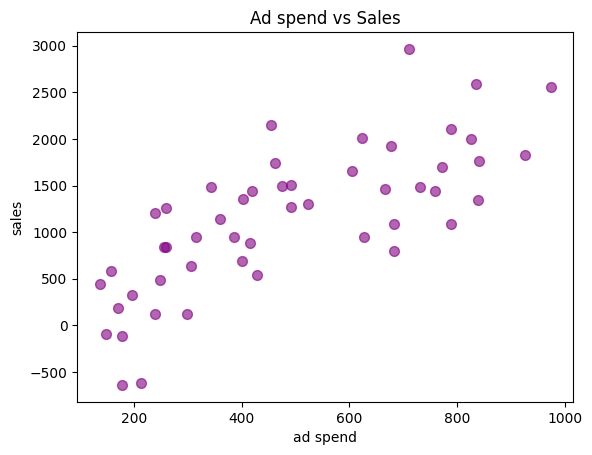

In [7]:
# ------------------------------------------------------------
# [목적] 산점도 — 두 값의 '관계'
# ------------------------------------------------------------
plt.scatter(ad_spend, sales, color='purple', alpha=0.6, s=50)  # 점 하나 = (광고비, 매출) 한 쌍
plt.xlabel('ad spend')                            # x = 광고비
plt.ylabel('sales')                               # y = 매출
plt.title('Ad spend vs Sales')
plt.show()

데이터 크기: (150, 4) | 종 이름: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


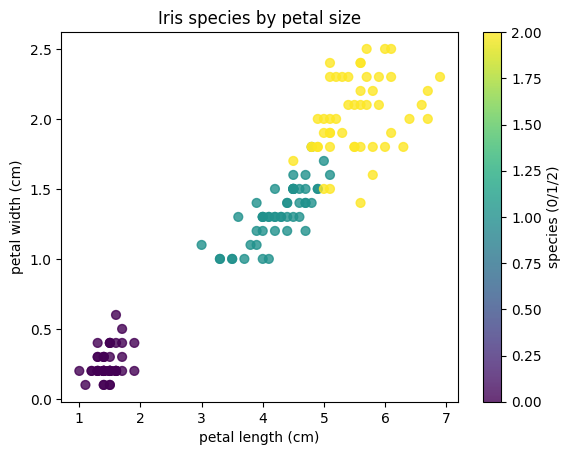

In [8]:
# ============================================================
# ★ 실전 예시 (다중분류) — 붓꽃 데이터로 '종별 산점도'(3색)
#   · 실습에서 다중분류(3종: setosa/versicolor/virginica)에 쓰던 데이터
#   · 꽃잎 길이 vs 꽃잎 너비 산점도를 '종별 색'으로 → 무리가 갈리는 게 보임
# ============================================================
from sklearn.datasets import load_iris            # 붓꽃 데이터 (다중분류 연습용, 3종)
iris = load_iris(as_frame=True)                   # 표로 불러오기
X, yv = iris.data, iris.target                    # X=특성 4개, yv=종(0/1/2)
print('데이터 크기:', X.shape, '| 종 이름:', list(iris.target_names))  # 크기·종 이름 확인

sc = plt.scatter(X['petal length (cm)'], X['petal width (cm)'],  # x=꽃잎길이, y=꽃잎너비
                 c=yv, cmap='viridis', alpha=0.8, s=40)          # c=종(색으로 구분), cmap=색표
plt.xlabel('petal length (cm)')                   # x = 꽃잎 길이
plt.ylabel('petal width (cm)')                    # y = 꽃잎 너비
plt.title('Iris species by petal size')           # 제목 (꽃잎 크기로 본 종)
plt.colorbar(sc, label='species (0/1/2)')          # 색막대 (색=어느 종인지)
plt.show()
# [결과 해석] 왼쪽아래 한 무리(보라, setosa)는 딱 떨어져 완전히 분리됨.
#            나머지 두 종은 오른쪽위에서 살짝 겹침 → 꽃잎 크기만으로 대부분 구분 가능.

데이터 크기: (442, 10) | target=1년 뒤 진행도(숫자)


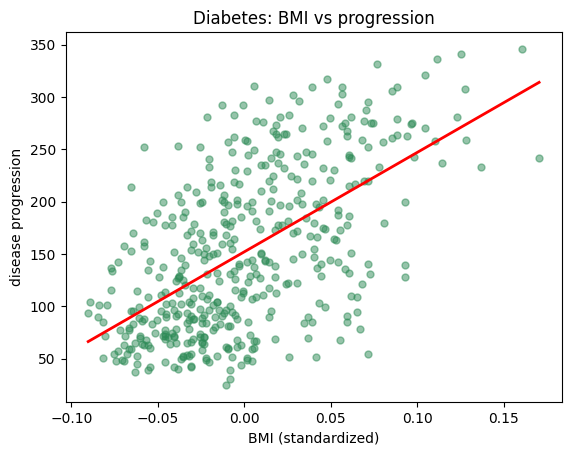

In [9]:
# ============================================================
# ★ 실전 예시 (회귀) — 당뇨 데이터로 'BMI vs 질병진행도' + 추세선
#   · 회귀 = 정답이 숫자(연속값)인 문제 (분류처럼 0/1이 아님)
#   · 산점도 위에 '추세선(직선)'을 얹으면 관계의 방향·세기가 한눈에 보임
# ============================================================
from sklearn.datasets import load_diabetes        # 당뇨 진행도 데이터 (회귀 연습용)
db = load_diabetes(as_frame=True)                 # 표로 불러오기
bmi = db.data['bmi']                              # 특성: 체질량지수(BMI, 표준화된 값)
prog = db.target                                  # 정답: 1년 뒤 질병진행도(숫자)
print('데이터 크기:', db.data.shape, '| target=1년 뒤 진행도(숫자)')  # 크기·정답 의미

plt.scatter(bmi, prog, alpha=0.5, s=25, color='seagreen')   # 점 = (BMI, 진행도) 한 명
m, b = np.polyfit(bmi, prog, 1)                   # 1차 추세선 기울기m·절편b (직선 맞추기)
xs = np.linspace(bmi.min(), bmi.max(), 100)       # 직선 그릴 x값들
plt.plot(xs, m * xs + b, color='red', linewidth=2)   # 빨간 추세선 (y = m*x + b)
plt.xlabel('BMI (standardized)')                  # x = 체질량지수
plt.ylabel('disease progression')                 # y = 질병 진행도
plt.title('Diabetes: BMI vs progression')          # 제목
plt.show()
# [결과 해석] 점들이 우상향으로 퍼지고 추세선도 오른쪽 위로 → BMI가 클수록 진행도도 높은
#            '양의 관계'. 회귀는 이런 '숫자→숫자' 관계를 직선/곡선으로 예측하는 문제.

In [10]:
# ============================================================
# [전체 정리]
#  · 그래프는 목적에 맞춰 고른다: 변화=선 / 분포=히스토그램 / 관계=산점도
#  · 이진분류(유방암): 특성을 '클래스별 히스토그램'으로 → 그룹이 갈리는지 확인
#  · 다중분류(붓꽃): 두 특성 '산점도 + 색'으로 → 여러 무리가 나뉘는지 확인
#  · 회귀(당뇨): '산점도 + 추세선'으로 → 숫자끼리의 관계 방향·세기 확인
#  · 즉, 같은 그래프라도 '무엇을 색/축에 놓느냐'로 분류·회귀 문제를 들여다볼 수 있다!
# ============================================================